In [22]:
import matplotlib.pyplot as plt
import geopandas
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler, MinMaxScaler
geopandas.options.io_engine = "pyogrio"

conn = sqlite3.connect('db.sqlite3')
cursor = conn.cursor()

data = conn.execute("""
with attendances_month as (
select
    sum(data.value) as value,
    data.commune_id as commune_id,
    data.report_id as report_id,
    data.year || '-' || (
        case data.cohort
            when 'Enero' then '01'
            when 'Febrero' then '02'
            when 'Marzo' then '03'
            when 'Abril' then '04'
            when 'Mayo' then '05'
            when 'Junio' then '06'
            when 'Julio' then '07'
            when 'Agosto' then '08'
            when 'Septiembre' then '09'
            when 'Octubre' then '10'
            when 'Noviembre' then '11'
            when 'Diciembre' then '12'
        end
    ) || '-01' as date
from data
where cohort in ('Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre')
  and data.year > 2020
group by date, commune_id, report_id
),
aqi_month as (
select
    commune_id,
    date(datetime, 'unixepoch', 'start of month') as date, -- collapse entire month to first day of month
    avg(case when contaminant = 'CO' then concentration end)     as CO,
    avg(case when contaminant = 'MP10' then concentration end)   as MP10,
    avg(case when contaminant = 'MP2.5' then concentration end)  as MP25,
    avg(case when contaminant = 'NO' then concentration end)     as NO,
    avg(case when contaminant = 'NO2' then concentration end)    as NO2,
    avg(case when contaminant = 'NOx' then concentration end)    as NOx,
    avg(case when contaminant = 'O3' then concentration end)     as O3,
    avg(case when contaminant = 'SO2' then concentration end)    as SO2
from contaminant
group by date, commune_id
)
select 
    attendances_month.date as date,
    commune.name as commune,
    attendances_month.value * 10000 / commune.population as attendances_10k,
    aqi_month.SO2 as SO2
from attendances_month
join aqi_month on aqi_month.date = attendances_month.date and aqi_month.commune_id = attendances_month.commune_id
join commune on commune.id = attendances_month.commune_id
join report on report.id = attendances_month.report_id
  and report.description = 'Ingresos Programa de Salud Mental por mes y año'
where SO2 is not null
""").fetchall()
# and attendances_month.date not in ('2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01') -- remove 2020 because of covid

data = pd.DataFrame(data, columns=['date', 'commune', 'Ingresos Programa de Salud Mental por mes y año','SO2'])

data


,date,commune,Ingresos Programa de Salud Mental por mes y año,SO2
0,2021-01-01,LA CISTERNA,16,2.254706
1,2021-01-01,PENALOLEN,19,1.008000
2,2021-01-01,PUENTE ALTO,10,1.286333
3,2021-02-01,LA CISTERNA,8,1.324444
4,2021-02-01,PENALOLEN,13,1.097857
...,...,...,...,...
90,2024-04-01,LA CISTERNA,32,4.002500
91,2024-04-01,PENALOLEN,26,3.711905
92,2024-05-01,PENALOLEN,27,4.157742
93,2024-06-01,LA CISTERNA,28,2.370385


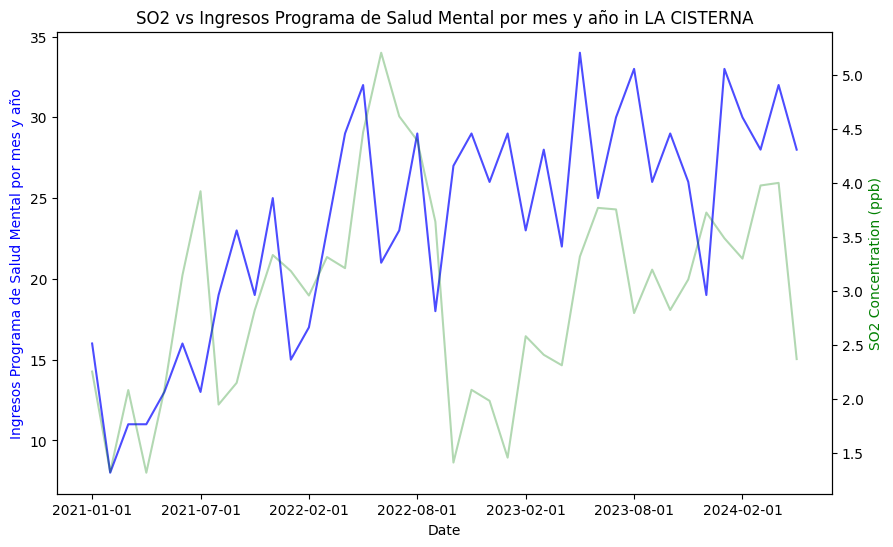

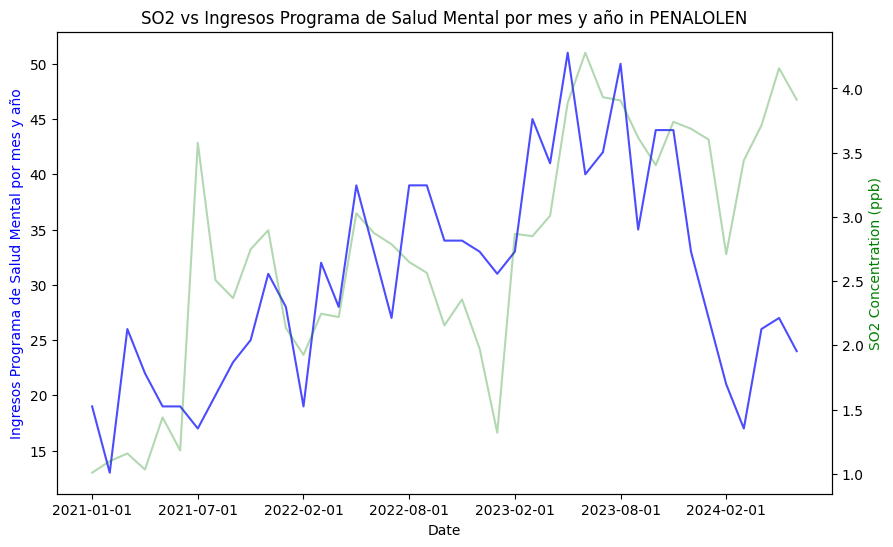

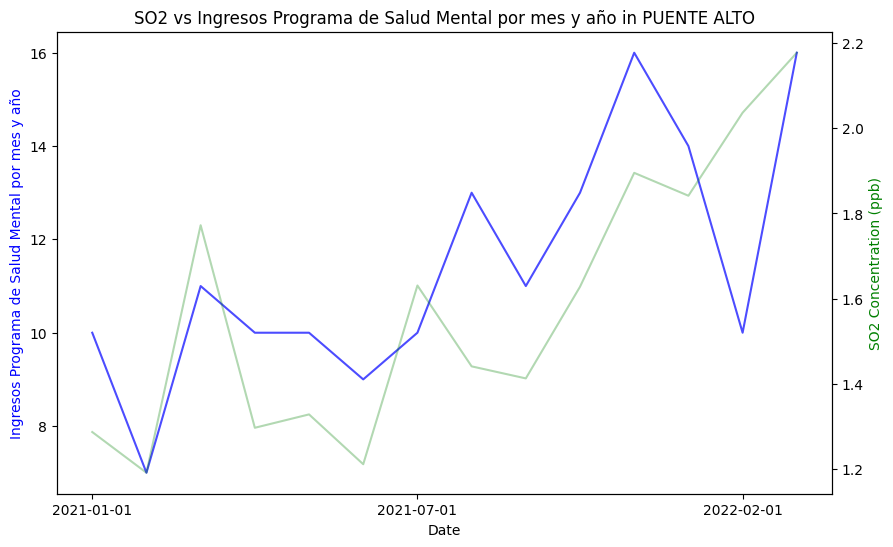

In [36]:
# plot so2 vs mental health attendances
for commune in data['commune'].unique():
    commune_data = data[data['commune'] == commune]
    fig, ax1 = plt.subplots(figsize=(10,6))
    ax2 = ax1.twinx()
    ax1.plot(commune_data['date'], commune_data['Ingresos Programa de Salud Mental por mes y año'], 'b-', alpha=0.7)
    ax2.plot(commune_data['date'], commune_data['SO2'], 'g-', alpha=0.3)
    ax1.set_xlabel('Date')
    # unclutter ax1 dates
    ax1.set_xticks(ax1.get_xticks()[::6])
    ax1.set_ylabel('Ingresos Programa de Salud Mental por mes y año', color='b')
    ax2.set_ylabel('SO2 Concentration (ppb)', color='g')
    plt.title(f'SO2 vs Ingresos Programa de Salud Mental por mes y año in {commune}')
    plt.savefig(f'img/so2_vs_mental_health_{commune}.png')